In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
df_dist_vs_disparity_train = pd.read_csv("train_depth_to_disparity.csv", header=None, names=['dist_mm', 'x_disparity_px', 'y_disparity_px'])
df_depth_vs_px_width_train = pd.read_csv("train_depth_to_px_width.csv", header=None, names=['dist_mm', 'pixel_width_mm'])
df_depth_vs_px_height_train = pd.read_csv("train_depth_to_px_height.csv", header=None, names=['dist_mm', 'pixel_height_mm'])

df_dist_vs_disparity_test = pd.read_csv("test_depth_to_disparity.csv", header=None, names=['dist_mm', 'x_disparity_px', 'y_disparity_px'])
df_depth_vs_px_width_test = pd.read_csv("test_depth_to_px_width.csv", header=None, names=['dist_mm', 'pixel_width_mm'])
df_depth_vs_px_height_test = pd.read_csv("test_depth_to_px_height.csv", header=None, names=['dist_mm', 'pixel_height_mm'])

In [18]:
def fit_reg(X_train, y_train, X_test, y_test):
    result = {}
    
    for deg in range(1,9):
        coeff = np.polyfit(X_train, y_train , deg=deg)
        # Create polynomial function
        p = np.poly1d(coeff)
        y_hat = p(X_test)
        RMSE = np.sqrt(mean_squared_error(y_test, y_hat))
        print(RMSE)
        result[RMSE] = p
        
    return result

# Fitting the polynomial to estimate depth (mm) from disparity (px). Identify the best performing degree of polynomial by evaluating against test data.

In [19]:
reg_models = {}

In [20]:
X_train = df_dist_vs_disparity_train['x_disparity_px']
X_test = df_dist_vs_disparity_test['x_disparity_px']
y_train = df_dist_vs_disparity_train['dist_mm']
y_test = df_dist_vs_disparity_test['dist_mm']
result = fit_reg(X_train, y_train, X_test, y_test)
best_rmse = min(result.keys())
best_p = result[best_rmse]

41.61999100802594
8.637726250641867
6.237213327070123
6.4273274315303635
6.439697138739804
6.551321369796346
6.585377223480631
7.042059193455926


In [21]:
reg_models['disparity_to_depth'] = best_p

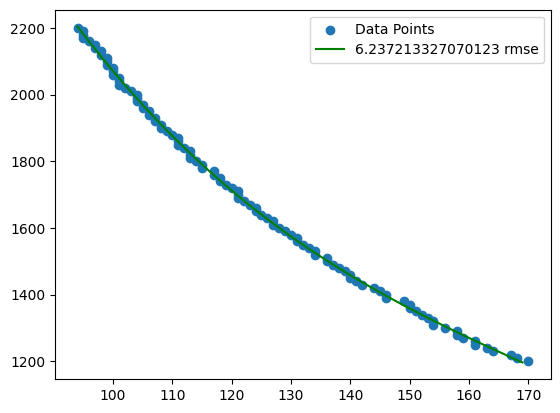

In [22]:
xp = np.arange(94, 170, 1)
plt.scatter(X_train, y_train, label='Data Points')
plt.plot(xp, best_p(xp), label=f'{best_rmse} rmse', color='green')
plt.legend()
plt.show()

# Fitting the polynomial to estimate pixel width (mm) from depth (mm). Identify the best performing degree of polynomial by evaluating against test data.

In [23]:
X_train = df_depth_vs_px_width_train['dist_mm']
X_test = df_depth_vs_px_width_test['dist_mm']
y_train = df_depth_vs_px_width_train['pixel_width_mm']
y_test = df_depth_vs_px_width_test['pixel_width_mm']
result = fit_reg(X_train, y_train, X_test, y_test)
best_rmse = min(result.keys())
best_p = result[best_rmse]

0.010005388873104778
0.010007578512798512
0.009962620313036777
0.010207804651948068
0.010241003957810926
0.010372076861424226
0.010499375342558105
0.010498074513940598


In [24]:
reg_models['depth_to_px_width_coeff'] = best_p

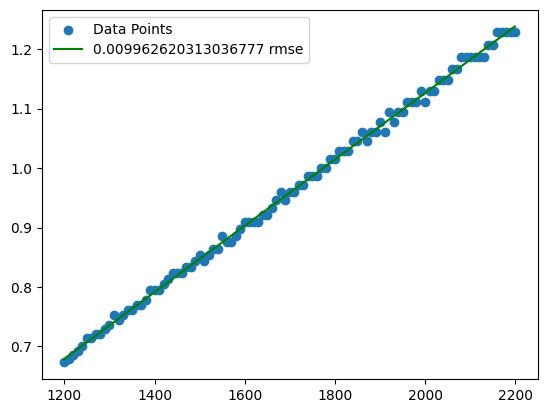

In [25]:
xp = np.arange(1200, 2200, 1)
plt.scatter(X_train, y_train, label='Data Points')
plt.plot(xp, best_p(xp), label=f'{best_rmse} rmse', color='green')
plt.legend()
plt.show()

# Fitting the polynomial to estimate pixel height (mm) from depth (mm). Identify the best performing degree of polynomial by evaluating against test data.

In [26]:
X_train = df_depth_vs_px_height_train['dist_mm']
X_test = df_depth_vs_px_height_test['dist_mm']
y_train = df_depth_vs_px_height_train['pixel_height_mm']
y_test = df_depth_vs_px_height_test['pixel_height_mm']
result = fit_reg(X_train, y_train, X_test, y_test)
best_rmse = min(result.keys())
best_p = result[best_rmse]

0.009813274151598819
0.010136492085537019
0.010176218686520078
0.01019240771136336
0.010047061700904749
0.010157253338340125
0.010141796058167998
0.010105909937519182


In [27]:
reg_models['depth_to_px_height_coeff'] = best_p

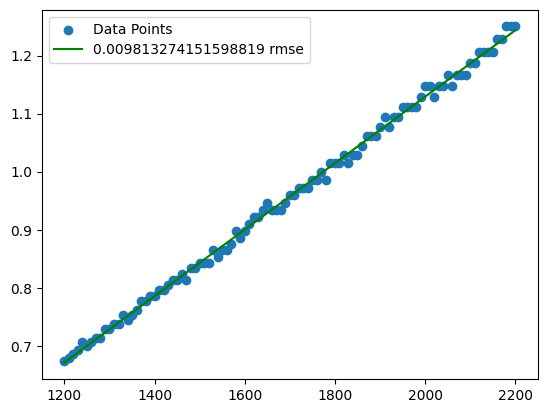

In [28]:
xp = np.arange(1200, 2200, 1)
plt.scatter(X_train, y_train, label='Data Points')
plt.plot(xp, best_p(xp), label=f'{best_rmse} rmse', color='green')
plt.legend()
plt.show()

In [29]:
reg_models

{'disparity_to_depth': poly1d([-8.13466355e-04,  4.23829500e-01, -8.15685991e+01,  6.80280369e+03]),
 'depth_to_px_width_coeff': poly1d([ 9.91443861e-12, -5.00797910e-08,  6.41299144e-04, -3.54750859e-02]),
 'depth_to_px_height_coeff': poly1d([ 0.00057212, -0.01521216])}

In [31]:
import pickle
with open("croppedframe_3d_reconstruction_regression_model.pkl", "wb") as models:    
        pickle.dump(reg_models, models, pickle.HIGHEST_PROTOCOL) # highest protocol version of pickle